In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

RANDOM_STATE = 42
os.makedirs("preprocessed_datasets", exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


In [16]:
train_raw = pd.read_csv("dataset/UNSW_NB15_train_40k.csv")
test_raw  = pd.read_csv("dataset/UNSW_NB15_test_10k.csv")

print(f"Train shape (raw) : {train_raw.shape}")
print(f"Test  shape (raw) : {test_raw.shape}")

Train shape (raw) : (175341, 36)
Test  shape (raw) : (82332, 36)


In [17]:
train = train_raw.drop(columns=["attack_cat"]).copy()
test  = test_raw.drop(columns=["attack_cat"]).copy()

print("Dropped 'attack_cat'.")
print(f"Train : {train.shape}  |  Test : {test.shape}")

Dropped 'attack_cat'.
Train : (175341, 35)  |  Test : (82332, 35)


In [18]:
n_before = len(train)
train = train.drop_duplicates().reset_index(drop=True)
n_after = len(train)

print(f"Train duplicates removed : {n_before - n_after:,}  ({(n_before - n_after) / n_before * 100:.2f}%)")
print(f"Train shape after dedup  : {train.shape}")
print(f"Test  unchanged          : {test.shape}")

Train duplicates removed : 82,984  (47.33%)
Train shape after dedup  : (92357, 35)
Test  unchanged          : (82332, 35)


In [19]:
assert train.isnull().sum().sum() == 0, "Missing values found in train!"
assert test.isnull().sum().sum()  == 0, "Missing values found in test!"
print("No missing values in train or test.")

No missing values in train or test.


In [20]:
NUM_COLS = train.select_dtypes(include=[np.number]).columns.tolist()
NUM_COLS = [c for c in NUM_COLS if c != "label"]

SKIP_CAP = {"is_ftp_login", "is_sm_ips_ports", "ct_ftp_cmd",
            "ct_flw_http_mthd", "trans_depth", "swin", "dwin"}


In [21]:
bounds = {}
for col in NUM_COLS:
    if col in SKIP_CAP:
        continue
    q1  = train[col].quantile(0.25)
    q3  = train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    bounds[col] = (lower, upper)
    train[col] = train[col].clip(lower=lower, upper=upper)
    test[col]  = test[col].clip(lower=lower, upper=upper)

print(f"Outlier capping applied to {len(bounds)} numerical features using train-set IQR bounds.")



Outlier capping applied to 24 numerical features using train-set IQR bounds.


In [22]:
skewness_post_cap = train[list(bounds.keys())].skew().abs().sort_values(ascending=False)
HIGH_SKEW = skewness_post_cap[skewness_post_cap > 5].index.tolist()

print(f"Applying log1p to {len(HIGH_SKEW)} high-skew features: {HIGH_SKEW}")

for col in HIGH_SKEW:
    train[col] = np.log1p(train[col])
    test[col]  = np.log1p(test[col])

print("log1p transformation complete.")

Applying log1p to 3 high-skew features: ['ackdat', 'synack', 'tcprtt']
log1p transformation complete.


In [ ]:
CAT_COLS = ["proto", "state", "service"]


proto_freq = train["proto"].value_counts(normalize=True)  
train["proto"] = train["proto"].map(proto_freq).fillna(0)
test["proto"]  = test["proto"].map(proto_freq).fillna(0)  
print(f"proto : frequency-encoded  (unique values collapsed to frequency ratio)")



for col in ["state", "service"]:
    train = pd.get_dummies(train, columns=[col], prefix=col, drop_first=False, dtype=int)
    test  = pd.get_dummies(test,  columns=[col], prefix=col, drop_first=False, dtype=int)


train_cols = set(train.columns)
test_cols = set(test.columns)

missing_in_test = train_cols - test_cols
extra_in_test = test_cols - train_cols

for col in missing_in_test:
    test[col] = 0

test = test.drop(columns=list(extra_in_test))
test = test[train.columns]  

print(f"state, service : one-hot encoded")
print(f"Train shape after encoding : {train.shape}")
print(f"Test  shape after encoding : {test.shape}")
print(f"Columns aligned between train and test.")

proto : frequency-encoded  (unique values collapsed to frequency ratio)
state, service : one-hot encoded
Train shape after encoding : (92357, 55)
Test  shape after encoding : (82332, 55)
Columns aligned between train and test.


In [24]:
X_train = train.drop(columns=["label"])
y_train = train["label"]

X_test  = test.drop(columns=["label"])
y_test  = test["label"]

print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")
print(f"\nClass distribution (train):\n{y_train.value_counts().rename({0:'Normal',1:'Attack'})}")

X_train : (92357, 54)  |  y_train : (92357,)
X_test  : (82332, 54)   |  y_test  : (82332,)

Class distribution (train):
label
Normal    48894
Attack    43463
Name: count, dtype: int64


In [25]:
X_train 

,dur,proto,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,state_CON,state_ECO,state_FIN,state_INT,state_PAR,state_REQ,state_RST,state_URN,state_no,service_-,service_dhcp,service_dns,service_ftp,service_ftp-data,service_http,service_irc,service_pop3,service_radius,service_smtp,service_snmp,service_ssh,service_ssl
0,0.1215,0.8190,6,4,258,172,74.0875,14158.9420,8495.3650,0.0000,0,24.2956,8.3750,30.1775,11.8306,255,621772692,2202533631,255,0.0000,0.0000,0.0000,43.0000,43,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,0.6499,0.8190,14,38,734,8983,78.4734,8395.1120,503571.3000,2.0000,16,49.9150,15.4329,61.4269,533.9687,255,1417884146,3077387971,255,0.0000,0.0000,0.0000,52.0000,455,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,1.6231,0.8190,8,16,364,8983,14.1702,1572.2719,60929.2300,1.0000,6,200.6001,102.7372,12083.7661,533.9687,255,2116150707,2963114973,255,0.1061,0.0596,0.0492,46.0000,455,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
3,1.6816,0.8190,12,12,628,770,13.6771,2740.1790,3358.6220,1.0000,3,152.8765,90.2357,259.0802,533.9687,255,1107119177,1047442890,255,0.0000,0.0000,0.0000,52.0000,64,0,0,1,1,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
4,0.4495,0.8190,10,6,534,268,33.3738,8561.4990,3987.0598,2.0000,1,47.7503,75.6596,2415.8376,115.8070,255,2436137549,1977154190,255,0.1208,0.0687,0.0557,53.0000,45,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92352,1.9143,0.8190,50,30,6543,2132,53.8053,288572.0000,8613.0290,14.5000,8,26.2139,65.0743,2412.3525,90.7736,255,556303757,246088519,255,0.0384,0.0268,0.0119,241.5000,71,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
92353,2.5441,0.8190,50,51,3086,8983,108.8970,6539.1987,914689.8000,6.0000,16,57.2171,10.9140,3358.3699,533.9687,255,3046870123,1723342386,255,0.0590,0.0253,0.0346,47.0000,455,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
92354,0.9965,0.8190,20,30,942,8983,49.1720,7185.1265,129476.7800,7.0000,13,52.4475,33.9374,3005.2560,533.9687,255,5604755,575257391,255,0.0440,0.0073,0.0369,47.0000,455,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
92355,1.5571,0.8190,28,22,6543,1954,31.4683,62427.8700,9586.8990,11.0000,8,57.6713,73.6914,3661.2131,112.4181,255,1932059121,2472223109,255,0.0441,0.0085,0.0359,241.5000,89,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [26]:
SCALE_COLS = X_train.select_dtypes(include=[np.number]).columns.tolist()

scaler = RobustScaler()
X_train[SCALE_COLS] = scaler.fit_transform(X_train[SCALE_COLS])
X_test[SCALE_COLS]  = scaler.transform(X_test[SCALE_COLS])

print(f"RobustScaler applied to {len(SCALE_COLS)} features.")
print(f"Fit on train only — no data leakage into test set.")

RobustScaler applied to 54 features.
Fit on train only — no data leakage into test set.


In [27]:
mi_scores = mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

MI_THRESHOLD = 0.001
drop_features = mi_series[mi_series < MI_THRESHOLD].index.tolist()

print(f"Total features before selection : {X_train.shape[1]}")
print(f"Features dropped (MI < {MI_THRESHOLD}): {len(drop_features)}")
print(drop_features)

X_train = X_train.drop(columns=drop_features)
X_test  = X_test.drop(columns=drop_features)

print(f"Features after selection : {X_train.shape[1]}")

Total features before selection : 54
Features dropped (MI < 0.001): 13
['response_body_len', 'is_ftp_login', 'service_dhcp', 'service_radius', 'service_snmp', 'ct_dst_sport_ltm', 'service_irc', 'state_no', 'state_URN', 'state_REQ', 'state_PAR', 'state_ECO', 'service_ssl']
Features after selection : 41


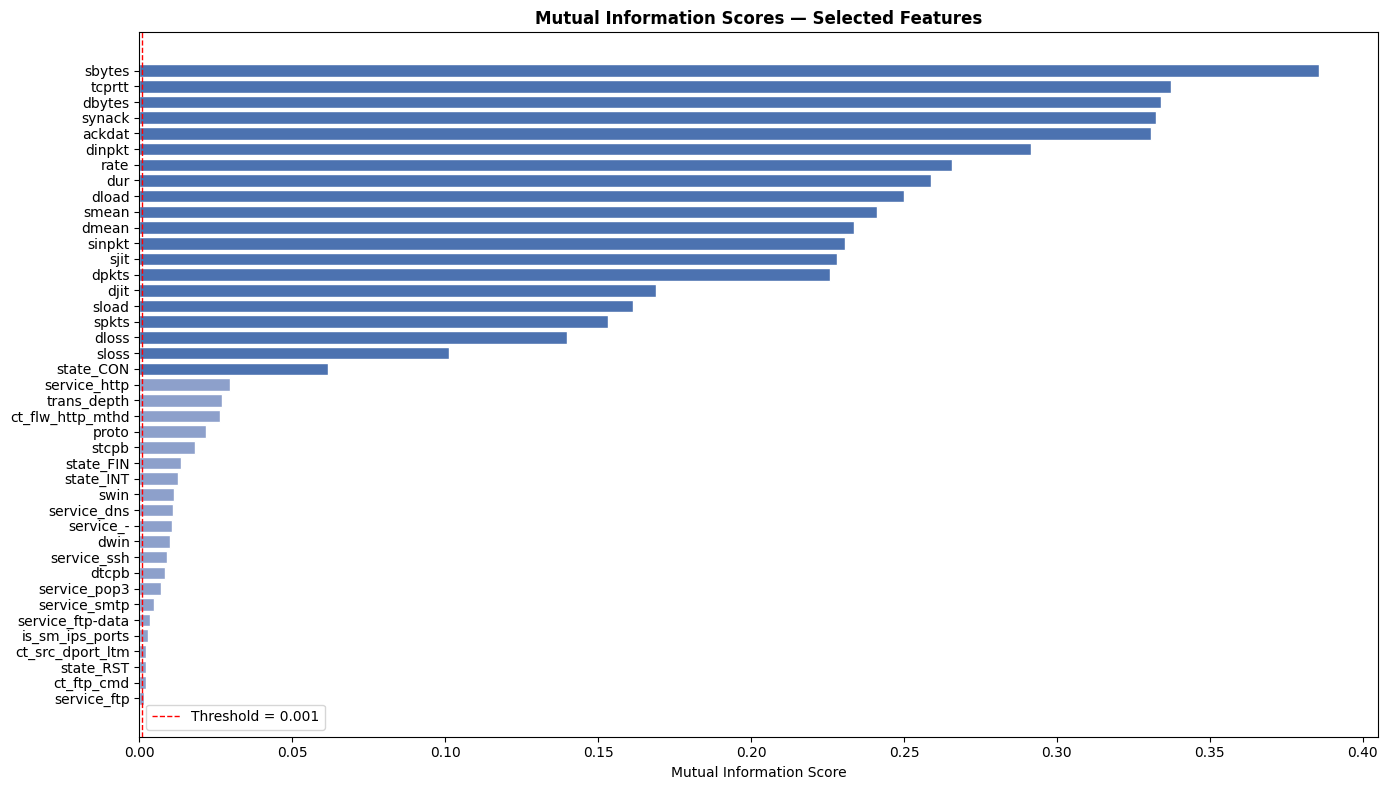

In [28]:
fig, ax = plt.subplots(figsize=(14, 8))
mi_selected = mi_series.drop(drop_features).sort_values()
colors = ["#4C72B0" if v >= 0.05 else "#8DA0CB" for v in mi_selected]
ax.barh(mi_selected.index, mi_selected.values, color=colors, edgecolor="white")
ax.axvline(MI_THRESHOLD, color="red", linewidth=1, linestyle="--", label=f"Threshold = {MI_THRESHOLD}")
ax.set_title("Mutual Information Scores — Selected Features", fontweight="bold")
ax.set_xlabel("Mutual Information Score")
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
print(f"Before SMOTE — Attack: {(y_train==1).sum():,}  Normal: {(y_train==0).sum():,}")

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"After  SMOTE — Attack: {(y_train_bal==1).sum():,}  Normal: {(y_train_bal==0).sum():,}")
print(f"Balanced train shape : {X_train_bal.shape}")

Before SMOTE — Attack: 43,463  Normal: 48,894
After  SMOTE — Attack: 48,894  Normal: 48,894
Balanced train shape : (97788, 41)


In [30]:
train_preprocessed = pd.DataFrame(X_train_bal, columns=X_train.columns)
train_preprocessed["label"] = y_train_bal.values

test_preprocessed  = pd.DataFrame(X_test, columns=X_test.columns)
test_preprocessed["label"]  = y_test.values

train_preprocessed.to_csv("preprocessed_datasets/train_preprocessed.csv", index=False)
test_preprocessed.to_csv("preprocessed_datasets/test_preprocessed.csv",   index=False)

print("Saved:")
print(f"  preprocessed_datasets/train_preprocessed.csv  — {train_preprocessed.shape}")
print(f"  preprocessed_datasets/test_preprocessed.csv   — {test_preprocessed.shape}")

Saved:
  preprocessed_datasets/train_preprocessed.csv  — (97788, 42)
  preprocessed_datasets/test_preprocessed.csv   — (82332, 42)


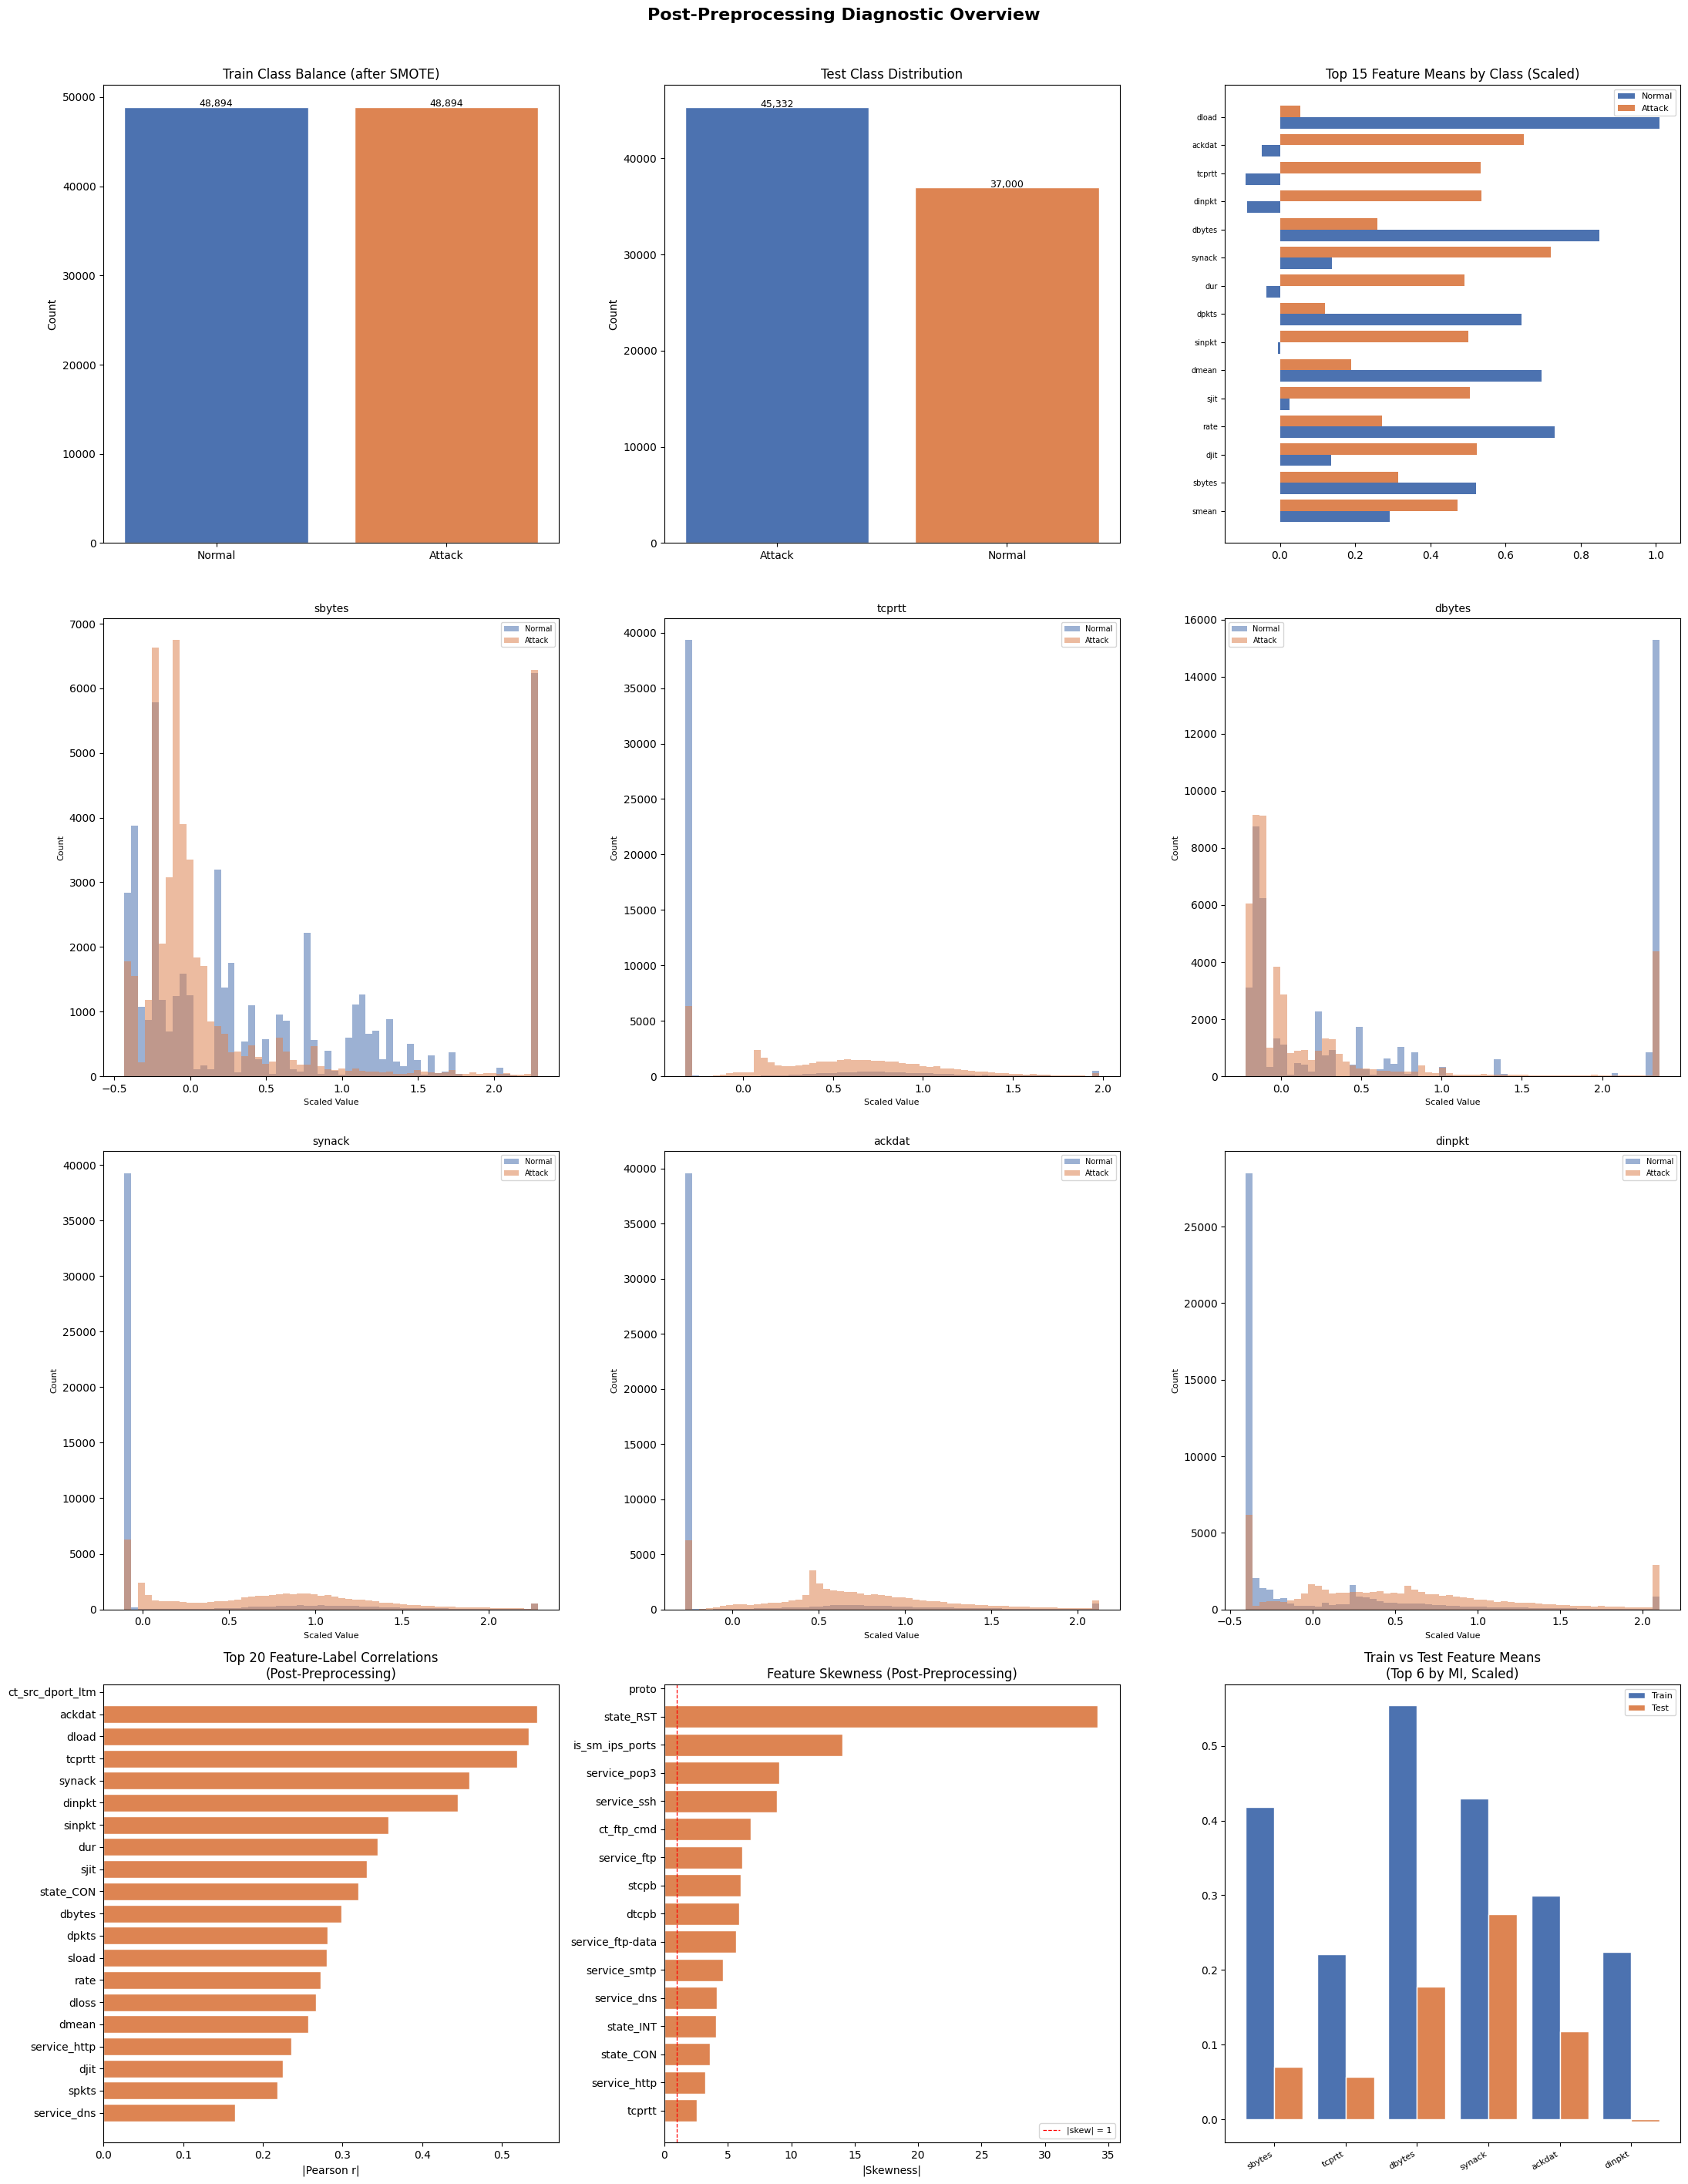


Post-preprocessing visualisation complete.
Train : (97788, 42)  |  Test : (82332, 42)


In [33]:
df_tr = pd.read_csv("preprocessed_datasets/train_preprocessed.csv")
df_te = pd.read_csv("preprocessed_datasets/test_preprocessed.csv")

feat_cols = [c for c in df_tr.columns if c != "label"]
num_feat  = df_tr[feat_cols].select_dtypes(include=[np.number]).columns.tolist()

fig = plt.figure(figsize=(22, 28))
fig.suptitle("Post-Preprocessing Diagnostic Overview", fontsize=16, fontweight="bold", y=1.01)

ax1 = fig.add_subplot(4, 3, 1)
bal = df_tr["label"].value_counts().rename({0: "Normal", 1: "Attack"})
ax1.bar(bal.index, bal.values, color=["#4C72B0", "#DD8452"], edgecolor="white")
for i, (lbl, val) in enumerate(bal.items()):
    ax1.text(i, val + 50, f"{val:,}", ha="center", fontsize=9)
ax1.set_title("Train Class Balance (after SMOTE)")
ax1.set_ylabel("Count")

ax2 = fig.add_subplot(4, 3, 2)
te_bal = df_te["label"].value_counts().rename({0: "Normal", 1: "Attack"})
ax2.bar(te_bal.index, te_bal.values, color=["#4C72B0", "#DD8452"], edgecolor="white")
for i, (lbl, val) in enumerate(te_bal.items()):
    ax2.text(i, val + 10, f"{val:,}", ha="center", fontsize=9)
ax2.set_title("Test Class Distribution")
ax2.set_ylabel("Count")

ax3 = fig.add_subplot(4, 3, 3)
top_feat = [c for c in num_feat if c in mi_series.nlargest(15).index][:15]
means = df_tr.groupby("label")[top_feat].mean().T
means.columns = ["Normal", "Attack"]
means["diff"] = (means["Attack"] - means["Normal"]).abs()
means = means.sort_values("diff", ascending=True)
y_pos = np.arange(len(means))
ax3.barh(y_pos - 0.2, means["Normal"], 0.4, label="Normal", color="#4C72B0")
ax3.barh(y_pos + 0.2, means["Attack"], 0.4, label="Attack",  color="#DD8452")
ax3.set_yticks(y_pos)
ax3.set_yticklabels(means.index, fontsize=7)
ax3.set_title("Top 15 Feature Means by Class (Scaled)")
ax3.legend(fontsize=8)

top6 = mi_series.nlargest(6).index.tolist()
for idx, col in enumerate(top6):
    ax = fig.add_subplot(4, 3, 4 + idx)
    # Get both subsets and compute bins from their combined range
    normal_subset = df_tr[df_tr["label"] == 0][col].values
    attack_subset = df_tr[df_tr["label"] == 1][col].values
    all_data = np.concatenate([normal_subset[~np.isnan(normal_subset)], 
                               attack_subset[~np.isnan(attack_subset)]])
    # Create bins using actual data range
    edge_min, edge_max = all_data.min(), all_data.max()
    bins = np.linspace(edge_min, edge_max, 61)
    # Plot both distributions without density to avoid shape issues
    ax.hist(normal_subset, bins=bins, alpha=0.55, color="#4C72B0", label="Normal", edgecolor="none")
    ax.hist(attack_subset, bins=bins, alpha=0.55, color="#DD8452", label="Attack", edgecolor="none")
    ax.set_title(f"{col}", fontsize=10)
    ax.set_xlabel("Scaled Value", fontsize=8)
    ax.set_ylabel("Count", fontsize=8)
    ax.legend(fontsize=7)

ax10 = fig.add_subplot(4, 3, 10)
corr_label = df_tr[num_feat + ["label"]].corr()["label"].drop("label").abs().sort_values(ascending=True).tail(20)
ax10.barh(corr_label.index, corr_label.values,
          color=["#DD8452" if v >= 0.1 else "#4C72B0" for v in corr_label.values],
          edgecolor="white")
ax10.set_title("Top 20 Feature-Label Correlations\n(Post-Preprocessing)")
ax10.set_xlabel("|Pearson r|")

ax11 = fig.add_subplot(4, 3, 11)
post_skew = df_tr[num_feat].skew().abs().sort_values(ascending=True).tail(20)
ax11.barh(post_skew.index, post_skew.values,
          color=["#DD8452" if v > 1 else "#55A868" for v in post_skew.values],
          edgecolor="white")
ax11.axvline(1, color="red", linewidth=0.9, linestyle="--", label="|skew| = 1")
ax11.set_title("Feature Skewness (Post-Preprocessing)")
ax11.set_xlabel("|Skewness|")
ax11.legend(fontsize=8)

ax12 = fig.add_subplot(4, 3, 12)
tr_means = df_tr[top6].mean()
te_means = df_te[top6].mean()
x = np.arange(len(top6))
ax12.bar(x - 0.2, tr_means.values, 0.4, label="Train", color="#4C72B0", edgecolor="white")
ax12.bar(x + 0.2, te_means.values, 0.4, label="Test",  color="#DD8452", edgecolor="white")
ax12.set_xticks(x)
ax12.set_xticklabels(top6, rotation=30, ha="right", fontsize=8)
ax12.set_title("Train vs Test Feature Means\n(Top 6 by MI, Scaled)")
ax12.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\nPost-preprocessing visualisation complete.")
print(f"Train : {df_tr.shape}  |  Test : {df_te.shape}")